# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Олійник Божена Орестівна'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-33'      # напр. 'КН-31'
ВАРІАНТ = 3     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Олійник Божена Орестівна, ШІ-33, варіант 3
ваш потік:                   P>10
ваша пара для графіка 3:     потік E>0.8 та потік P>10
ваш агрегат для етапу 4:     середнє
ваше додаткове питання:      Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
import pandas as pd
df = pd.read_excel("20171129_FINAL_FINAL.xlsx", sheet_name='Sheet1')
print(df.dtypes)
display(df.head())

Unnamed: 0                                     float64
ftp://ftp.swpc.noaa.gov/pub/lists/particle/     object
Unnamed: 2                                      object
Unnamed: 3                                      object
Unnamed: 4                                      object
Unnamed: 5                                      object
Unnamed: 6                                      object
Unnamed: 7                                      object
Unnamed: 8                                      object
Unnamed: 9                                      object
Unnamed: 10                                     object
Unnamed: 11                                     object
Unnamed: 12                                     object
Unnamed: 13                                     object
Unnamed: 14                                     object
Unnamed: 15                                    float64
Unnamed: 16                                     object
Unnamed: 17                                     object
Unnamed: 1

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


**Відповідь 1.1:** *Дані в таблиці починаються не з 1 рядка, перші рядки мають дані про файл та коментаріб, саме тоу при виводі ми отримали отакий результат*

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
import pandas
df_raw = pd.read_excel("20171129_FINAL_FINAL.xlsx", sheet_name='Sheet1', header=None)
print("Розмір таблиці: ", df_raw.shape)
display(df_raw.head(30))

Розмір таблиці:  (7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
counts = df_raw.notna().sum()

print("Заповнені клітинки у стовпці:")
print(counts.to_string())

Заповнені клітинки у стовпці:
0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602


**Відповідь 1.3:** *Всього є три таблиці: 1 - займає 1-14 стовпці, 2 - 16-19 стовпці, 3 - 28-31 стовпці*

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
for text in df_raw.iloc[0:40, 16].dropna():
    print(text)

ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt
Product: Daily Solar Data         quar_DSD.txt
:Issued: 0825 UT 04 Oct 2017
#
#  Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
#  Please send comments and suggestions to SWPC.Webmaster@noaa.gov
Quarterly Daily Solar Data
2017
2017
2017
2017
2017
2017
2017
2017
2017
2017
2017
2017
2017


**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center | Protons/cm2-s-sr, Electrons/cm2-s-sr |
| B | U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center | No information was provided |
| C | SOHO CELIAS Proton Monitor | Proton speed (km/sec), Proton density(protons per kubic centimeter), Measurement time |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
A = df_raw.iloc[:, 1:15].copy()

A.columns = ['Year', 'Month', 'Day', 'Hour', 'Minute', 
             'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 
             'E>0.8', 'E>2.0', 'E>4.0']

A = A.apply(pd.to_numeric, errors='coerce').dropna(how='all')


B = df_raw.iloc[:, 16:20].copy()

B.columns = ['Year', 'Month', 'Day', 'F10.7']

B = B.apply(pd.to_numeric, errors='coerce').dropna(how='all')

C = df_raw.iloc[:, 26:32].copy()
C.columns = ['Year', 'Month', 'Day', 'Hour', 'Speed_km_s', 'Density_p_cm3']
C = C.apply(pd.to_numeric, errors='coerce').dropna(how='all')

print(f"Розмір A: {A.shape}")
print(f"Розмір B: {B.shape}")
print(f"Розмір C: {C.shape}")

display(A.head())

Розмір A: (7200, 14)
Розмір B: (25, 4)
Розмір C: (601, 6)


,Year,Month,Day,Hour,Minute,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,E>4.0
26,2017.0,8.0,28.0,0.0,57993.0,0.0,12.00,0.260,0.180,0.1140,0.1040,0.0793,23600.0,1180.0
27,2017.0,8.0,28.0,5.0,57993.0,300.0,19.40,0.690,0.314,0.1120,0.0612,0.0251,23100.0,1160.0
28,2017.0,8.0,28.0,10.0,57993.0,600.0,8.48,0.168,0.130,0.0717,0.0614,0.0304,22200.0,1090.0
29,2017.0,8.0,28.0,15.0,57993.0,900.0,15.40,0.566,0.198,0.0926,0.0568,0.0251,20400.0,997.0
30,2017.0,8.0,28.0,20.0,57993.0,1200.0,6.41,0.156,0.118,0.0597,0.0494,0.0251,18500.0,875.0


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
A['h'] = A.iloc[:, 3] // 100
A['m'] = A.iloc[:, 3] % 100
A['ts'] = pd.to_datetime(dict(year=A.iloc[:, 0], month=A.iloc[:, 1], day=A.iloc[:, 2], hour=A['h'], minute=A['m']), errors='coerce')

B['ts'] = pd.to_datetime(dict(year=B.iloc[:, 0], month=B.iloc[:, 1], day=B.iloc[:, 2]), errors='coerce')

c_year = C['Year'].copy()
c_year.loc[c_year < 100] += 2000
C['ts'] = pd.to_datetime(dict(year=c_year, month=C['Month'], day=C['Day'], hour=C['Hour']), errors='coerce')

print(f"A: з {A['ts'].min()} до {A['ts'].max()}")
print(f"B: з {B['ts'].min()} до {B['ts'].max()}")
print(f"C: з {C['ts'].min()} до {C['ts'].max()}")

A: з 2017-08-28 00:00:00 до 2017-09-21 23:55:00
B: з 2017-08-28 00:00:00 до 2017-09-21 00:00:00
C: з 2017-08-28 00:00:00 до 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
tables = {'A': A, 'B': B, 'C': C}

for name, df in tables.items():
    print(f"Таблиця {name}")
    print(f"1.Розмір: {df.shape}")
    print("\n2.Типи стовпців:")
    print(df.dtypes)
    print("\n3.Кількість пропусків у кожному стовпці:")
    print(df.isna().sum())
    print(f"\n4.Кількість повних дублікатів: {df.duplicated().sum()}")
    print("\n5.Описова статистика:")
    display(df.describe())

Таблиця A
1.Розмір: (7200, 17)

2.Типи стовпців:
Year             float64
Month            float64
Day              float64
Hour             float64
Minute           float64
P>1              float64
P>5              float64
P>10             float64
P>30             float64
P>50             float64
P>100            float64
E>0.8            float64
E>2.0            float64
E>4.0            float64
h                float64
m                float64
ts        datetime64[us]
dtype: object

3.Кількість пропусків у кожному стовпці:
Year      0
Month     0
Day       0
Hour      0
Minute    0
P>1       0
P>5       3
P>10      3
P>30      3
P>50      3
P>100     3
E>0.8     3
E>2.0     3
E>4.0     3
h         0
m         0
ts        0
dtype: int64

4.Кількість повних дублікатів: 0

5.Описова статистика:


,Year,Month,Day,Hour,Minute,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,E>4.0,h,m,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200.000000,7200.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,11.500000,27.500000,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,0.000000,0.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,5.750000,13.750000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,11.500000,27.500000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,17.250000,41.250000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,23.000000,55.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,6.922667,17.261461,NaN


Таблиця B
1.Розмір: (25, 5)

2.Типи стовпців:
Year            float64
Month           float64
Day             float64
F10.7           float64
ts       datetime64[us]
dtype: object

3.Кількість пропусків у кожному стовпці:
Year     0
Month    0
Day      0
F10.7    0
ts       0
dtype: int64

4.Кількість повних дублікатів: 0

5.Описова статистика:


,Year,Month,Day,F10.7,ts
count,25.0,25.000000,25.000000,25.000000,25
mean,2017.0,8.840000,13.960000,92.680000,2017-09-09 00:00:00
min,2017.0,8.000000,1.000000,71.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,74.000000,2017-09-03 00:00:00
50%,2017.0,9.000000,13.000000,84.000000,2017-09-09 00:00:00
75%,2017.0,9.000000,19.000000,107.000000,2017-09-15 00:00:00
max,2017.0,9.000000,31.000000,140.000000,2017-09-21 00:00:00
std,0.0,0.374166,8.955817,22.206831,NaN


Таблиця C
1.Розмір: (601, 7)

2.Типи стовпців:
Year                    float64
Month                   float64
Day                     float64
Hour                    float64
Speed_km_s              float64
Density_p_cm3           float64
ts               datetime64[us]
dtype: object

3.Кількість пропусків у кожному стовпці:
Year             0
Month            0
Day              0
Hour             0
Speed_km_s       0
Density_p_cm3    0
ts               0
dtype: int64

4.Кількість повних дублікатів: 0

5.Описова статистика:


,Year,Month,Day,Hour,Speed_km_s,Density_p_cm3,ts
count,601.0,601.000000,601.000000,601.000000,601.000000,601.000000,601
mean,17.0,8.840266,13.973378,11.480865,506.547421,2.907654,2017-09-09 12:00:00
min,17.0,8.000000,1.000000,0.000000,-1.000000,-1.000000,2017-08-28 00:00:00
25%,17.0,9.000000,7.000000,5.000000,447.000000,1.800000,2017-09-03 06:00:00
50%,17.0,9.000000,13.000000,11.000000,517.000000,2.400000,2017-09-09 12:00:00
75%,17.0,9.000000,19.000000,17.000000,584.000000,3.400000,2017-09-15 18:00:00
max,17.0,9.000000,31.000000,23.000000,806.000000,31.700000,2017-09-22 00:00:00
std,0.0,0.366664,8.781000,6.938063,125.073291,2.637873,NaN


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
cols = ['Speed_km_s', 'Density_p_cm3']

print("Від'ємних записів:")
for col in cols:
    negative = (C[col] < 0).sum()
    print(f"  {col}: {negative}")

before = C[cols].agg(['min', 'mean'])

for col in cols:
    C.loc[C[col] < 0, col] = None 

after = C[cols].agg(['min', 'mean'])

for col in cols:
    print(f"\nСтовпець: {col}")
    print(f"  Min: {before.loc['min', col]:.2f}  -  {after.loc['min', col]:.2f}")
    print(f"  Mean: {before.loc['mean', col]:.2f}  -  {after.loc['mean', col]:.2f}")

Від'ємних записів:
  Speed_km_s: 8
  Density_p_cm3: 8

Стовпець: Speed_km_s
  Min: -1.00  -  277.00
  Mean: 506.55  -  513.39

Стовпець: Density_p_cm3
  Min: -1.00  -  0.10
  Mean: 2.91  -  2.96


**Відповідь 3.2:** *Від'ємні значення - відсутні записи, в обидвох колонках було по 8 таких значень, вони занижували середнє та мінімалье значення*

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
time_cols = [col for col in A.columns]

time_stats = A[time_cols].describe()

display(time_stats)

,Year,Month,Day,Hour,Minute,P>1,P>5,P>10,P>30,P>50,P>100,E>0.8,E>2.0,E>4.0,h,m,ts
count,7200.0,7200.000000,7200.000000,7200.000000,7200.000000,7200.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.00000,7197.000000,7197.000000,7200.000000,7200.000000,7200
mean,2017.0,8.840000,13.960000,1177.500000,58005.000000,43050.000000,689.325064,156.626057,76.474020,18.838604,7.446840,1.65929,81862.741801,11401.502123,11.500000,27.500000,2017-09-09 11:57:30
min,2017.0,8.000000,1.000000,0.000000,57993.000000,0.000000,0.429000,0.151000,0.117000,0.057600,0.045500,0.02240,4.300000,0.133000,0.000000,0.000000,2017-08-28 00:00:00
25%,2017.0,9.000000,7.000000,588.750000,57999.000000,21525.000000,11.700000,0.279000,0.186000,0.098400,0.059700,0.02630,22200.000000,552.000000,5.750000,13.750000,2017-09-03 05:58:45
50%,2017.0,9.000000,13.000000,1177.500000,58005.000000,43050.000000,55.400000,0.632000,0.376000,0.146000,0.086600,0.03630,68600.000000,4290.000000,11.500000,27.500000,2017-09-09 11:57:30
75%,2017.0,9.000000,19.000000,1766.250000,58011.000000,64575.000000,560.000000,107.000000,35.800000,0.990000,0.249000,0.06700,143000.000000,14100.000000,17.250000,41.250000,2017-09-15 17:56:15
max,2017.0,9.000000,31.000000,2355.000000,58017.000000,86100.000000,32500.000000,2890.000000,1330.000000,399.000000,191.000000,61.50000,259000.000000,110000.000000,23.000000,55.000000,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,6.922667,17.261461,NaN


**Відповідь 3.3:** *На мою думку, колонки Year, Month, Day, Hour, Minute, h, m не немуть ніякого сенсу. оскільки є показниками часу, коли було отримано той, чи інший показник, проте вони не є одиницями вимірювання*

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
cols = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0', 'E>4.0']
A_hourly = (A.set_index('ts')[cols]
    .resample('1h')
    .agg(['mean', 'max'])
    .reset_index()
)

display(A_hourly.head())

ts      P>1                P>5             P>10             P>30             P>50             P>100             E>0.8                 E>2.0                 E>4.0        
                          mean      max      mean    max      mean    max      mean    max      mean     max      mean     max      mean     max          mean      max         mean     max
0 2017-08-28 00:00:00   1650.0   3300.0  9.778333  19.40  0.324917  0.690  0.192917  0.314  0.098850  0.2240  0.077583  0.1780  0.040692  0.0793  20941.666667  23600.0  1011.583333  1180.0
1 2017-08-28 01:00:00   5250.0   6900.0  7.994167  13.60  0.291667  0.512  0.156583  0.259  0.072583  0.0919  0.058700  0.0798  0.029950  0.0471  18091.666667  20600.0   713.000000   907.0
2 2017-08-28 02:00:00   8850.0  10500.0  6.099167  10.80  0.283000  0.479  0.177667  0.321  0.084450  0.1210  0.069642  0.1110  0.035025  0.0595  14108.333333  15000.0   380.833333   475.0
3 2017-08-28 03:00:00  12450.0  14100.0  4.752500   7.76  0.236833  0.329  0.166333  0.244  0.087658  0.1800  0.068092  0.1390  0.035517  0.0818  12766.666667  13100.0   267.916667   284.0
4 2017-08-28 04:00:00  16050.0  17700.0  4.158333   6.62  0.334917  0.539  0.208333  0.309  0.084800  0.1530  0.072850  0.1420  0.039708  0.0694  11333.333333  12300.0   203.000000   234.0

### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

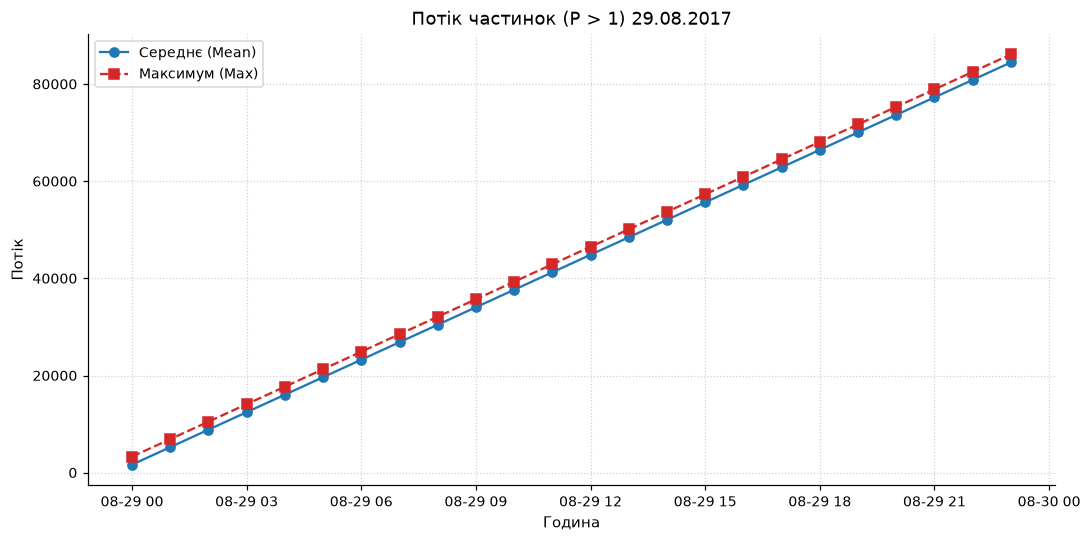

In [15]:
day = (A['ts'] >= '2017-08-29') & (A['ts'] < '2017-08-30')
A_day = A.loc[day].copy()

hourly_stats = (
    A_day.set_index('ts')['P>1']
    .resample('1h')
    .agg(['mean', 'max'])
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(hourly_stats['ts'], hourly_stats['mean'], label='Середнє (Mean)', marker='o', color='tab:blue')
plt.plot(hourly_stats['ts'], hourly_stats['max'], label='Максимум (Max)', marker='s', linestyle='--', color='tab:red')

plt.title('Потік частинок (P > 1) 29.08.2017', fontsize=12)
plt.xlabel('Година', fontsize=10)
plt.ylabel('Потік', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()



**Відповідь 4.2:** *Максимум має значення більше, за середнє, що означає, що потік частинок не завжди максимальний*

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
B_hourly = B.set_index('ts').resample('1h').ffill().reset_index()

C = C.drop_duplicates(subset=['ts'])

A_prep = A_hourly.copy()
if isinstance(A_prep.columns, pd.MultiIndex):
    A_prep.columns = ['_'.join(c).strip('_') for c in A_prep.columns]

M_inner = A_prep.merge(C, on='ts', how='inner').merge(B_hourly, on='ts', how='inner')
M_outer = A_prep.merge(C, on='ts', how='outer').merge(B_hourly, on='ts', how='outer')

print(f"Розмір при inner: {M_inner.shape[0]}")
print(f"Розмір при outer: {M_outer.shape[0]}")

M = M_outer

nan_rows = M[M.isna().any(axis=1)]
print(f"Рядки з пропусками: {len(nan_rows)}")
display(nan_rows)


Розмір при inner: 577
Розмір при outer: 601
Рядки з пропусками: 32


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max,E>4.0_mean,E>4.0_max,Year_x,Month_x,Day_x,Hour,Speed_km_s,Density_p_cm3,Year_y,Month_y,Day_y,F10.7
175,2017-09-04 07:00:00,26850.0,28500.0,6.465833,10.10,0.262083,0.593,0.171500,0.294,0.085483,0.145,0.068558,0.1340,0.031717,0.0523,90600.000000,100000.0,7410.833333,8950.0,17.0,9.0,4.0,7.0,NaN,NaN,2017.0,9.0,4.0,140.0
176,2017-09-04 08:00:00,30450.0,32100.0,4.010833,5.08,0.256000,0.432,0.195833,0.336,0.086625,0.145,0.070033,0.1340,0.036492,0.0546,73483.333333,79300.0,5048.333333,5850.0,17.0,9.0,4.0,8.0,NaN,NaN,2017.0,9.0,4.0,140.0
177,2017-09-04 09:00:00,34050.0,35700.0,3.268333,4.42,0.303417,0.518,0.220333,0.302,0.105925,0.162,0.081975,0.1340,0.046483,0.0765,60475.000000,68500.0,3715.833333,4480.0,17.0,9.0,4.0,9.0,NaN,NaN,2017.0,9.0,4.0,140.0
178,2017-09-04 10:00:00,37650.0,39300.0,3.179167,4.74,0.252167,0.372,0.181833,0.280,0.101900,0.150,0.081675,0.1200,0.054125,0.0894,64383.333333,68400.0,4122.500000,4710.0,17.0,9.0,4.0,10.0,NaN,NaN,2017.0,9.0,4.0,140.0
179,2017-09-04 11:00:00,41250.0,42900.0,5.274167,7.98,0.295083,0.657,0.186917,0.276,0.089525,0.166,0.063983,0.1100,0.033633,0.0684,79933.333333,88200.0,6345.833333,7430.0,17.0,9.0,4.0,11.0,NaN,NaN,2017.0,9.0,4.0,140.0
180,2017-09-04 12:00:00,44850.0,46500.0,2.965000,4.85,0.217750,0.428,0.153500,0.239,0.089217,0.179,0.071217,0.1440,0.037233,0.0679,80516.666667,88700.0,6080.000000,7420.0,17.0,9.0,4.0,12.0,NaN,NaN,2017.0,9.0,4.0,140.0
181,2017-09-04 13:00:00,48450.0,50100.0,3.061667,3.86,0.275833,0.551,0.192833,0.329,0.104542,0.170,0.083783,0.1590,0.041342,0.0611,76733.333333,85900.0,6015.833333,7540.0,17.0,9.0,4.0,13.0,NaN,NaN,2017.0,9.0,4.0,140.0
182,2017-09-04 14:00:00,52050.0,53700.0,7.279167,10.80,0.231333,0.409,0.170583,0.313,0.086508,0.178,0.070667,0.1660,0.037375,0.0888,83025.000000,90200.0,8552.500000,10500.0,17.0,9.0,4.0,14.0,NaN,NaN,2017.0,9.0,4.0,140.0
577,2017-09-21 01:00:00,5250.0,6900.0,37.408333,56.30,0.268250,0.375,0.196667,0.335,0.116075,0.255,0.078192,0.1600,0.039483,0.0737,159833.333333,164000.0,38200.000000,41400.0,17.0,9.0,21.0,1.0,453.0,1.9,NaN,NaN,NaN,NaN
578,2017-09-21 02:00:00,8850.0,10500.0,36.841667,48.60,0.357250,0.774,0.229333,0.493,0.100842,0.154,0.071567,0.1290,0.038883,0.0737,150583.333333,158000.0,32333.333333,36000.0,17.0,9.0,21.0,2.0,453.0,1.9,NaN,NaN,NaN,NaN


**Відповідь 4.3:** *При outer типі об'єднання записів виходить більше, ніж при inner, оскільки він вміщує в себе всі записи з обох таблиць, на відміну від inner, який зберігає лише спільні записи, які перетинаються в обох таблицях. Обирає outer, оскільки так всі дані будуть збережні та обробка буде точніша.*

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [17]:
conditions = [
    M['P>10_max'] < 10,
    (M['P>10_max'] >= 10) & (M['P>10_max'] < 1000),
    M['P>10_max'] >= 1000
]

choices = ['тиха', 'активна', 'дуже активна']

M['група'] = np.select(conditions, choices, default='активна')

print("Годин у групі:")
print(M['група'].value_counts(dropna=False))

Годин у групі:
група
тиха            397
активна         166
дуже активна     38
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

Середнє: 156.590
Медіана: 0.601


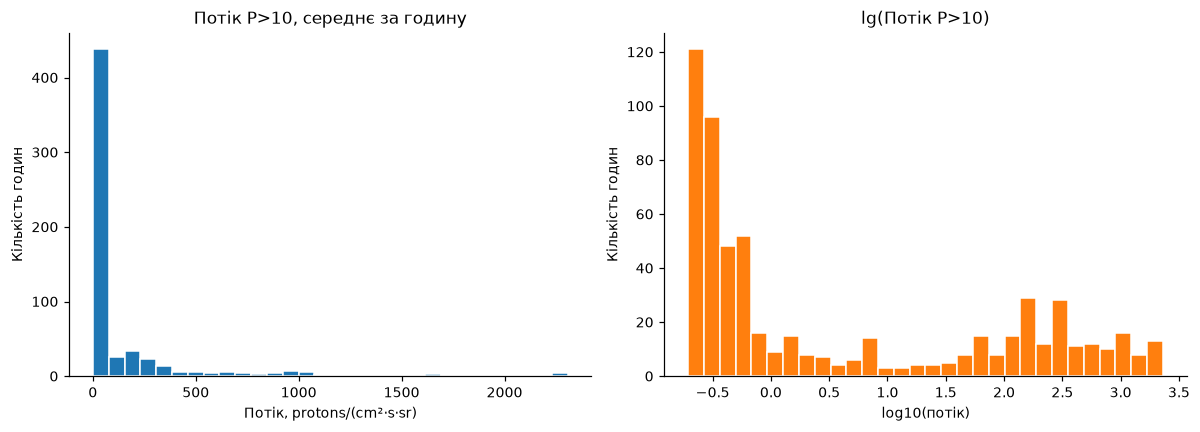

In [19]:
values = M['P>10_mean'].dropna()

середнє = values.mean()
медіана = values.median()
print(f"Середнє: {середнє:.3f}")
print(f"Медіана: {медіана:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(values, bins=30, color='tab:blue', edgecolor='white')
axes[0].set_title('Потік P>10, середнє за годину')
axes[0].set_xlabel('Потік, protons/(cm²·s·sr)')
axes[0].set_ylabel('Кількість годин')

axes[1].hist(np.log10(values[values > 0]), bins=30, color='tab:orange', edgecolor='white')
axes[1].set_title('lg(Потік P>10)')
axes[1].set_xlabel('log10(потік)')
axes[1].set_ylabel('Кількість годин')

plt.tight_layout()
plt.show()

**Висновок:** *Медіана значно менша за середнє, оскільки ри вирахування середнього значення враховується декілька годин з сильними сплесками, хоч таких дуже мало, проте значення в ці години настільки велике, що й середнє значення стає досить великим, в той час як медіана вираховує значення, яек було протягом більшої кількості годин, що, як видно на графіку, число близьке до 0*

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

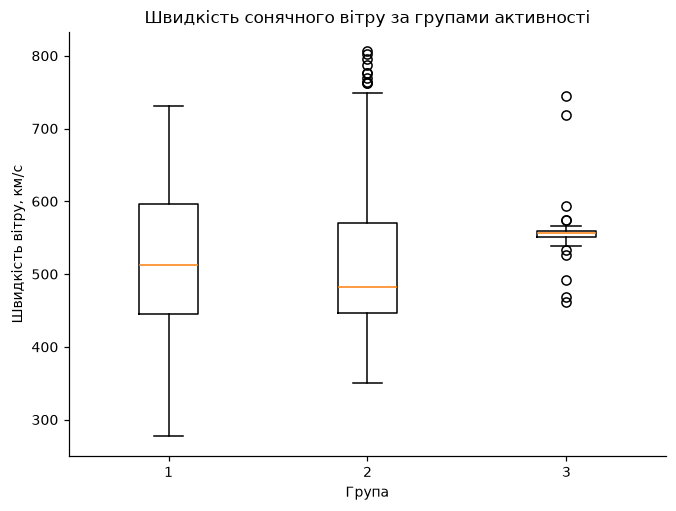

In [20]:
groups_order = ['тиха', 'активна', 'дуже активна']
data_by_group = [M.loc[M['група'] == g, 'Speed_km_s'].dropna() for g in groups_order]

plt.figure(figsize=(7, 5))
plt.boxplot(data_by_group, label=groups_order)
plt.title('Швидкість сонячного вітру за групами активності')
plt.xlabel('Група')
plt.ylabel('Швидкість вітру, км/с')
plt.show()

**Висновок:** *Медіана швидкості в різних групах відрізнаяється, проте не сильно, на відміну від загального діапазону швидостей. У тихій групі він найширший, оскільки вона вміщує найбільшу кількість записів, у наступних групах, по мірі зменшення записів в них, зменшується і діапазон можливих швидкостей*

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Коефіцієнт кореляції: 0.764


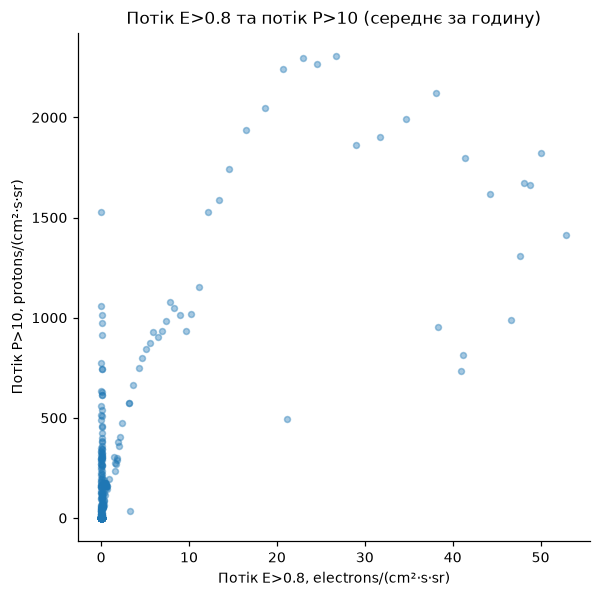

In [ ]:
x = M['E>0.8_mean']
y = M['P>10_mean']

corr = M[['E>0.8_mean', 'P>10_mean']].corr().iloc[0, 1]
print(f"Коефіцієнт кореляції: {corr:.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.4, s=15)
plt.title('Потік E>0.8 та потік P>10 (середнє за годину)')
plt.xlabel('Потік E>0.8, electrons/(cm²·s·sr)')
plt.ylabel('Потік P>10, protons/(cm²·s·sr)')
plt.show()

**Висновок:** *Досить високий коефіцієнт кореляції вказує на те, що значення, здебільшого, ростуть пропорційно, тобто - при збільшенні потоку Е збільшується і потік Р, проте на початку графіку, біля 0, зростання набагато різкіше, тобто при меншій активнсті кореляція сильніша*

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

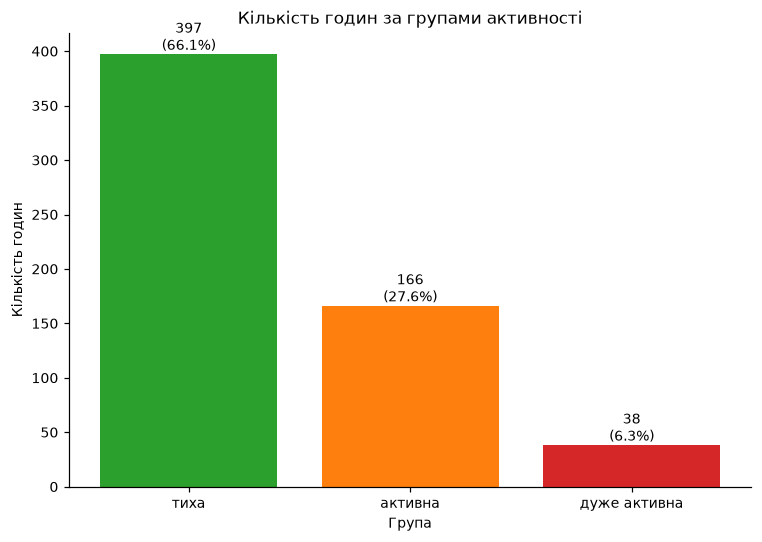

In [22]:
groups_order = ['тиха', 'активна', 'дуже активна']
counts = M['група'].value_counts().reindex(groups_order)
total = counts.sum()

plt.figure(figsize=(7, 5))
bars = plt.bar(counts.index, counts.values, color=['tab:green', 'tab:orange', 'tab:red'])

for bar, count in zip(bars, counts.values):
    pct = 100 * count / total
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
              f'{count}\n({pct:.1f}%)', ha='center', va='bottom')

plt.title('Кількість годин за групами активності')
plt.xlabel('Група')
plt.ylabel('Кількість годин')
plt.tight_layout()
plt.show()

**Висновок:** *Більшість годин (аж 66%, прибоизно 400 годин) попало в тиху групу, тоді як активна група має близько 175 записів, а дуже активна менше 50 годин, що свідчить про те, що більшість часу активність була спокійна з одиночними сплесками*

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

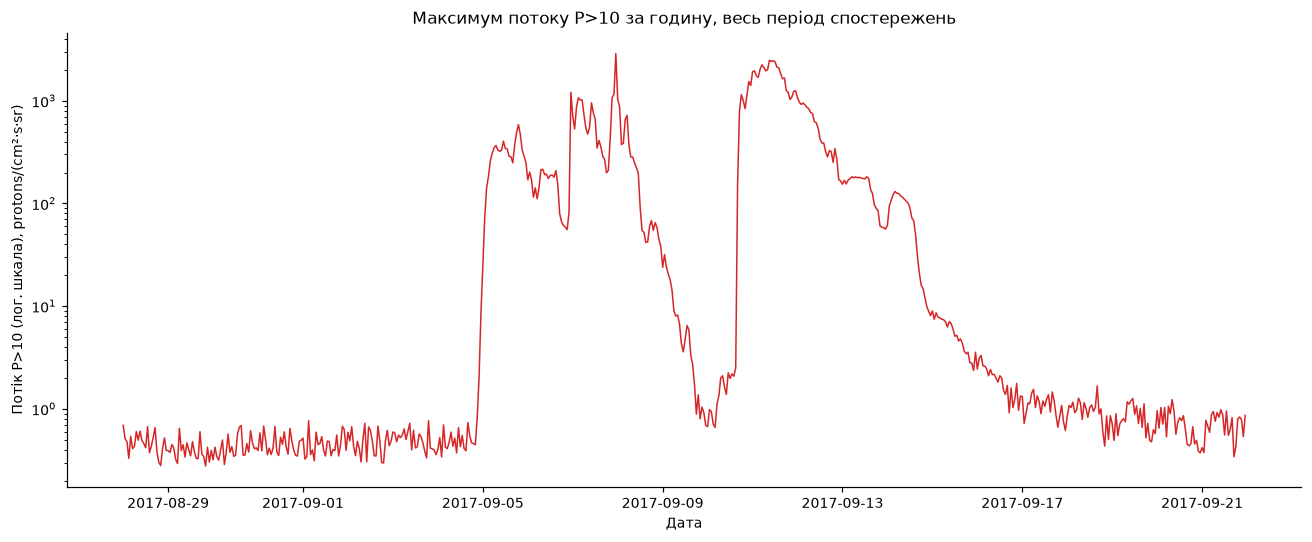

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(M['ts'], M['P>10_max'], color='tab:red', linewidth=1)
plt.yscale('log')
plt.title('Максимум потоку P>10 за годину, весь період спостережень')
plt.xlabel('Дата')
plt.ylabel('Потік P>10 (лог. шкала), protons/(cm²·s·sr)')
plt.tight_layout()
plt.show()

**Висновок:** *До 5 вересня потік був спокійним, в період від 5 до 9 вересня відбувся сильний сплеск активності, тоді на декілька днів (10-11 вересня) активність спала, а потім знову 11 вересня різко підвищилась. 14-15 вересня активність почала падати і решту місяць продовжувала бути спокійною. Основна активність сконкетрована у період з 5 по 15 вересня*

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

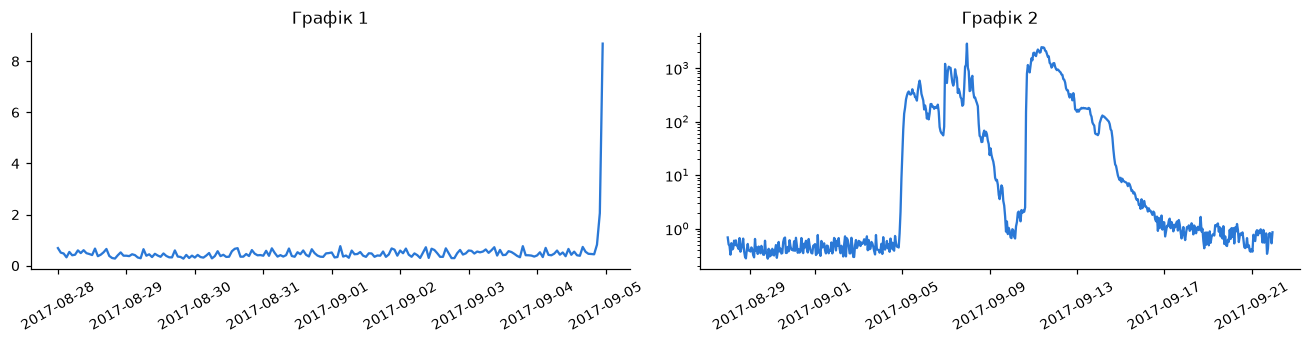

In [24]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: людина побачить стабільний графік з майже рівними показниками впродовж всього місяця (окрім сплеску в самому кінці), та вирішить що весь час погода була стабільною а активність спокійною
2. Висновок з другого графіка: людина побачить два сильних сплески активності, та зробить висновок що в місяці були спокійні періоди, та декілька днів сильної активності
3. Дві відмінності між ними: першиц графік показує лише перший тиждень місяця з спокійною погодою, тоді як другий графік показує активність за весь місяць, включно з бурями та спокійними періодами. Також відрізняються масштаби осі У, на другому графіку вона має значно вищу шкалу та показує сплески набагто точніше, тоді як перша шкала їх згладжує


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

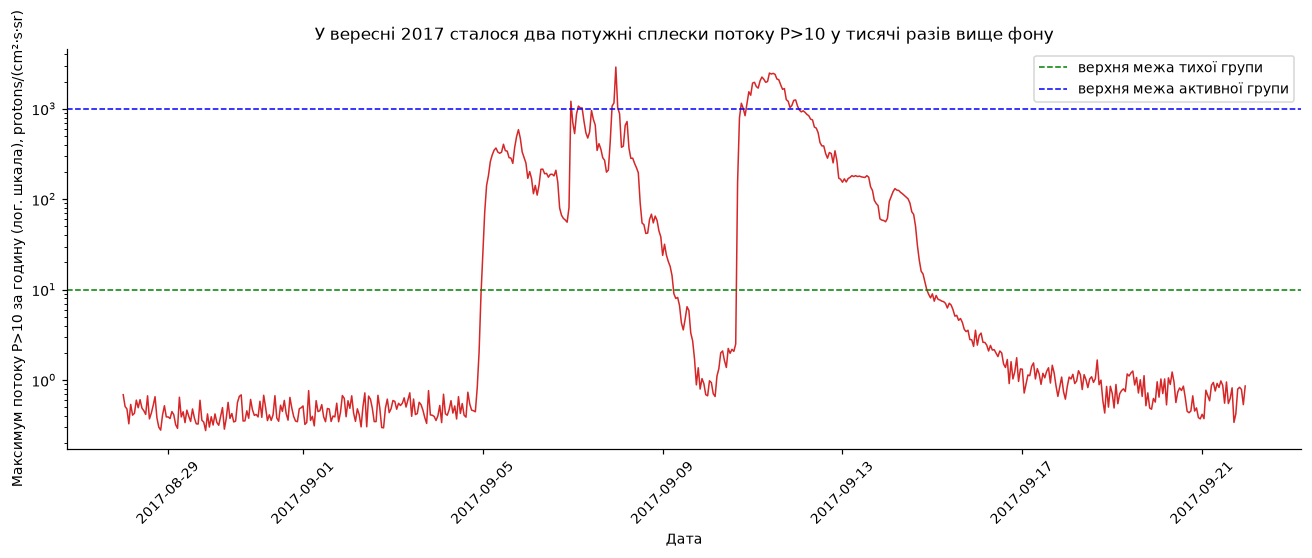

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(M['ts'], M['P>10_max'], color='tab:red', linewidth=1)
plt.yscale('log')
plt.axhline(10, color='green', linestyle='--', linewidth=1, label='верхня межа тихої групи ')
plt.axhline(1000, color='blue', linestyle='--', linewidth=1, label='верхня межа активної групи')
plt.title('У вересні 2017 сталося два потужні сплески потоку P>10 у тисячі разів вище фону')
plt.xlabel('Дата')
plt.ylabel('Максимум потоку P>10 за годину (лог. шкала), protons/(cm²·s·sr)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**Відповідь 6.2:** *Обираю саме такий графік, оскільки він показує погоду потягом всього місяця, як сплески так і спокійні періоди, що довзоляє точніше зрозуміти загальну картину активності у вересні. Також додала лінії-маркери для візуальноо розподілення активностей на групи*

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** *Найбільший сплеск активності у вересні зафіксовано у другій четверті місяця (з 5 по 14 число), тоді які періоди до та після цього сплеску, погода була спокійна. Це спостережння видно на графіку 5 на 5 етапі роботи*

**Спостереження 2:** *Найбільша кількість годин знаходиться у третій групі (близько 400 годин), тоді як у активній та дуже актвній групах сумарно записів близько 200, тобто 2/3 з усіх годин належать саме тихій групі, що свідчить по переважно спокійну погодую Сопстереження виявлено у завданні 4.4*

**Спостереження 3:** *Відсутні записи у колоках швидкості та густини у таблиці С сильно впливали на середнє та мінімальне значення цих колонок, тим самим спотворюючи результати. Спосетереження видно у задванні 3.2*


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [29]:
# Яка частка від загальної суми потоку була отримана у 24 години навколо піку?

потік_колонка = 'P>10_mean'

пік_idx = M[потік_колонка].idxmax()
пік_час = M.loc[пік_idx, 'ts']
пік_значення = M.loc[пік_idx, потік_колонка]

вікно_24h = M[(M['ts'] >= пік_час - pd.Timedelta(hours=12)) &
              (M['ts'] <= пік_час + pd.Timedelta(hours=12))]

сума_загальна = M[потік_колонка].sum()
сума_вікна = вікно_24h[потік_колонка].sum()
частка = 100 * сума_вікна / сума_загальна

print(f"Момент піку: {пік_час}")
print(f"Значення в піку: {пік_значення:.3f}")
print(f"Загальна сума потоку: {сума_загальна:.3f}")
print(f"Сума потоку у 24 години навколо піку: {сума_вікна:.3f}")
print(f"Частка від загальної суми: {частка:.2f}%")


Момент піку: 2017-09-11 09:00:00
Значення в піку: 2306.667
Загальна сума потоку: 93953.887
Сума потоку у 24 години навколо піку: 42241.333
Частка від загальної суми: 44.96%


**Відповідь 7.2:** *Найвище годинне значення потоку P>10 (його пік) припадає на 5 вересні, коли відбувся найбільший стрибок активності. Добове вікно навколо цього піку дає велику частку від загального сумарного значення. Хоча ці 24 години це лише невеличка частина від приблизних 600 годин всього вікна спостережень, вони формують майже половину сумарноо значення за весь місяць. Це пояснюється висновокм з графіка 1: розподіл активностей потоку днерівномірний і саме години аномальної активності визначають її сумарнй рівень*

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [31]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'     

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'код, перевірено',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'код, перевірено',
    'етапи 6–7, порівняння графіків і спостереження': 'ні',
}

ЩО_ПЕРЕВІРЕНО = "Для етапів 1-2 перевірила, що межі стовпців кожної з трьох таблиць (A, B, C) збігаються з описом над таблицями, а розмір після очищення дорівнює очікуваним 7200/25/601 рядкам. Для графіків перевірила, що підписи осей відповідають справжнім одиницям вимірювання із опису таблиць."

ПІДТВЕРДЖУЮ = True

In [32]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Олійник Божена Орестівна
інструменти:                                   Gemini
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    код, перевірено
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                код, перевірено
етапи 6–7, порівняння графіків і спостереження: ні
------------------------------------------------------------------------------
перевірено автором:
Для етапів 1-2 перевірила, що межі стовпців кожної з трьох таблиць (A, B, C) збігаються з описом над таблицями, а розмір після очищення дорівнює очікуваним 7200/25/601 рядкам. Для графіків перевірила, що підписи осей відповідають справжнім одиницям вимірювання із опису таблиць.
Автор п

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [33]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 30)


In [34]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
